# Multiagent Pattern - Multiagent Collaboration

<img src="../img/multiagent_pattern.png" alt="Alt text" width="500"/>

---

You may have heard about frameworks like [CrewAI](https://www.crewai.com/) or [AutoGen](https://microsoft.github.io/autogen/0.2/), which allow you to create multi-agent applications.

These frameworks implement different variations of the multi-agent pattern, in which tasks are divided into **smaller subtasks executed by different roles** (e.g. one agent can be a software engineer, another a project manager, etc.)

For this final lesson, I wanted to build something more elaborate. That's why I've been working on a 𝐦𝐢𝐧𝐢𝐦𝐚𝐥𝐢𝐬𝐭 𝐯𝐞𝐫𝐬𝐢𝐨𝐧 𝐨𝐟 𝐂𝐫𝐞𝐰𝐀𝐈, drawing inspiration from two of its key concepts: 𝐂𝐫𝐞𝐰 and 𝐀𝐠𝐞𝐧𝐭.

Additionally, I've also borrowed ideas from [𝐀𝐢𝐫𝐟𝐥𝐨𝐰](https://airflow.apache.org/)'𝐬 𝐝𝐞𝐬𝐢𝐠𝐧 𝐩𝐡𝐢𝐥𝐨𝐬𝐨𝐩𝐡𝐲, using >> and << to define dependencies between my agents. In this micro-CrewAI, 𝐚𝐠𝐞𝐧𝐭𝐬 are equivalent to 𝐀𝐢𝐫𝐟𝐥𝐨𝐰 𝐓𝐚𝐬𝐤𝐬 and the 𝐂𝐫𝐞𝐰 is equivalent to an 𝐀𝐢𝐫𝐟𝐥𝐨𝐰 𝐃𝐀𝐆.

Take a look at the previous lessons if you haven't!

* [First Lesson: The Reflection Pattern](https://github.com/neural-maze/agentic_patterns/blob/main/notebooks/reflection_pattern.ipynb)
* [Second Lesson: The Tool Pattern](https://github.com/neural-maze/agentic_patterns/blob/main/notebooks/tool_pattern.ipynb)
* [Third Lesson: The Planning Pattern](https://github.com/neural-maze/agentic_patterns/blob/main/notebooks/planning_pattern.ipynb)

**Let's begin!!** 💪

## The Agent Class

First of all, we need an **Agent Class**. This class implements an
Agent, and internally it implements the ReAct technique (check [Lesson 3](https://github.com/neural-maze/agentic_patterns/blob/main/notebooks/planning_pattern.ipynb) if you want to see this technique in detail!).

In [28]:
from agentic_patterns.multiagent_pattern.agent import Agent

Let's create some example agent, to see how it works.

In [29]:

#MODEL = "openai/gpt-oss-120b"
MODEL = "meta-llama/llama-4-scout-17b-16e-instruct"
#MODEL = "openai/gpt-oss-20b"
#MODEL = "qwen/qwen3-32b"
#MODEL = "moonshotai/kimi-k2-instruct-0905"

agent_example = Agent(
    name="Poet Agent",
    backstory="You are a well-known poet, who enjoys creating high quality poetry.",
    task_description="Write a poem about the meaning of life",
    task_expected_output="Just output the poem, without any title or introductory sentences",
    llm = MODEL,
)

In [30]:
print(agent_example.run())

In whispers of wind, in shadows of night
The meaning of life, a question takes flight
A mystery that has puzzled hearts and minds
For centuries, a quest that left us blind

In stars up high, in earth below
We search for answers, as the moments flow
A fleeting glimpse, a moment's peace
A sense of purpose, our souls to release

Is it love that drives us, or is it pain?
The pursuit of happiness, or the end of gain?
Is it in the laughter, or in the tears?
The meaning of life, through all our fears

Perhaps it's in the journey, not the end
The path we take, the love we lend
The connections we make, the hearts we touch
The memories we create, the moments we clutch

In the stillness, in the quiet night
The meaning of life, a spark takes flight
A flame that burns, a light that guides
A sense of purpose, that in our hearts resides

It's not in the destination, but the ride
The twists and turns, the ups and downs we glide
The meaning of life, a story we create
A tale of love, of joy, of fate

In

You can also associate tools with the agent. Let's create a tool for writing some string into a CSV.

In [31]:
from agentic_patterns.tool_pattern.tool import tool

In [32]:
@tool
def write_str_to_txt(string_data: str, txt_filename: str):
    """
    Writes a string to a txt file.

    This function takes a string and writes it to a text file. If the file already exists, 
    it will be overwritten with the new data.

    Args:
        string_data (str): The string containing the data to be written to the file.
        txt_filename (str): The name of the text file to which the data should be written.
    """
    # Write the string data to the text file
    with open(txt_filename, mode='w', encoding='utf-8') as file:
        file.write(string_data)

    print(f"Data successfully written to {txt_filename}")

In [33]:
agent_tool_example = Agent(
    name="Writer Agent",
    backstory="You are a language model specialised in writing text into .txt files",
    task_description="Write the string 'This is a Tool Agent' into './tool_agent_example.txt'",
    task_expected_output="A .txt file containing the given string",
    llm = MODEL,
    tools=write_str_to_txt,
)

In [34]:
agent_tool_example.run()

'A .txt file containing the given string has been created.'

## Defining Agent Dependencies

Let's define two agents now.

In [35]:
agent_1 = Agent(
    name="Poet Agent",
    backstory="You are a well-known poet, who enjoys creating high quality poetry.",
    task_description="Write a poem about the meaning of life",
    task_expected_output="Just output the poem, without any title or introductory sentences",
    llm = MODEL,
)

agent_2 = Agent(
    name="Poem Translator Agent",
    backstory="You are an expert translator especially skilled in Ancient Greek",
    task_description="Translate a poem into Ancient Greek", 
    task_expected_output="Just output the translated poem and nothing else",
    llm = MODEL,
)

We can define the agent dependencies using the `>>` operator.

In [36]:
agent_1 >> agent_2

Poem Translator Agent

This means `agent_2` depends on `agent_1`. We can check the dependencies and dependents of both agents.

In [37]:
print("Agent 1 dependencies: ", agent_1.dependencies)
print("Agent 1 dependents: ", agent_1.dependents)
print("Agent 2 dependencies: ", agent_2.dependencies)
print("Agent 2 dependents: ", agent_2.dependents)

Agent 1 dependencies:  []
Agent 1 dependents:  [Poem Translator Agent]
Agent 2 dependencies:  [Poet Agent]
Agent 2 dependents:  []


Now, if we run `agent_1`, the results will be added to `agent_2`'s context.

In [38]:
print(agent_1.run())

In whispers of wind, in shadows of night
A question echoes, a seeker's plight
What is the meaning, the purpose we chase?
A mystery that time cannot erase

In stars that twinkle, in oceans so blue
We search for answers, both old and new
A glimpse of truth, a ray of light
To guide us through life's plodding night

Is it in love, in laughter, in tears?
Or in the silence that calms our fears?
Perhaps it's in moments we share
With others, with ourselves, with the air

The search for meaning, a journey we take
Through trials and tribulations we make
Our own path, our own way, our own voice
In the grand symphony, a single choice

And when the winds of time begin to fade
And our footsteps on earth are delayed
The meaning we sought, the purpose we claimed
Is it in the memories we created, the love we proclaimed?

Maybe the meaning is not something we find
But something we create, leave behind
A legacy of kindness, of courage, of heart
A spark that ignites, a work of art

In the end, it's not th

In [39]:
print(agent_2.context)

Poem Translator Agent received context: 
In whispers of wind, in shadows of night
A question echoes, a seeker's plight
What is the meaning, the purpose we chase?
A mystery that time cannot erase

In stars that twinkle, in oceans so blue
We search for answers, both old and new
A glimpse of truth, a ray of light
To guide us through life's plodding night

Is it in love, in laughter, in tears?
Or in the silence that calms our fears?
Perhaps it's in moments we share
With others, with ourselves, with the air

The search for meaning, a journey we take
Through trials and tribulations we make
Our own path, our own way, our own voice
In the grand symphony, a single choice

And when the winds of time begin to fade
And our footsteps on earth are delayed
The meaning we sought, the purpose we claimed
Is it in the memories we created, the love we proclaimed?

Maybe the meaning is not something we find
But something we create, leave behind
A legacy of kindness, of courage, of heart
A spark that ignite

Now, if we run the second agent, it will use the context received from the previous agent to generate its output.

In [40]:
print(agent_2.run())

Ἐν ψιθύροις ἀέτος, ἐν σκιᾶς νυκτός
Ἐρώτημα ἠχō, πλάνητος ἄνδρα ἁμαρτία
Τί ἐστιν ἡ σημασία, τὸ τέλος ᾧ διώκομεν;
Αἰνίγματα ἃ χρόνος οὐκ ἐξαλείφει

Ἐν ἀστériς οἳ τρεμέουσιν, ἐν ὠκεάνοις οἳ ἄναξαν
Ζητοῦμεν ἀπαντήσεις, παλαιὰς καὶ νέας
Γλῶσσαν ἀληθείας, ῥαδίον φῶς
Περὶ βίου τῆς νυκτός, ὅταν ἡμέρα ἔλθῃ

Ἐν ἀγάπῃ ἐστὶν, ἐν γέλωτι, ἐν δάκρυσιν;
Ἤ ἐν σιωπῇ, ἅτις παύει φόβον;
Τὰς στιγμὰς ἣς μερίζομεν
Μετὰ ἄλλων, μετὰ ἑαυτῶν, μετὰ ἀέρος

Τὸ ζήτημα τῆς σημασίας, ὁδοιπορία ἣν λαμβάνουμεν
Διὰ δοκιμασιῶν καὶ πονηρίων ἣν ὁδεύομεν
Ἰδίαν ὁδόν, ἴδιον τρόπον, ἴδιον φωνήν
Ἐν τῆς ζωῆς συμφωνία, μίαν ἐπιλογήν

Καὶ ὅταν αἱ ὄνειροι τοῦ χρόνου ἄρξονται ἀπαυλάνει
Καὶ αἱ ἴχναι ἡμῶν ἐπὶ γῆς καθυστερῶνται
Τὴν σημασίαν ἣν ἐζητούμεν, τὸ τέλος ᾧ ἐκαυχήσαμεν
Ἐν ταῖς μνήμαις ἣς ἐδημιουργήσαμεν, ἀγάπης ἣν ἐκηρύξαμεν;

Ἴσως ἡ σημασία οὐκ ἔστιν ὃ ἰστορέωμεν
Ἀλλὰ ὃ δημιουργούμεν, ὑπολείπωμεν
Κληρονομίαν εὐμένειας, ἀνδρείας, καρδίας
Σπινθήρα ἣν ἐκκαίομεν, ἕργον τεχνῆς

Ἐν τέλει, οὐκ ἔστιν ἔτη ἣς ζῶμεν
Ἀλλὰ τὴν ζωήν ἣν ζῶμεν

## The Crew

In [41]:
from agentic_patterns.multiagent_pattern.crew import Crew

In [42]:
with Crew() as crew:
    agent_1 = Agent(
        name="Poet Agent",
        backstory="You are a well-known poet, who enjoys creating high quality poetry.",
        task_description="Write a poem about the meaning of life",
        task_expected_output="Just output the poem, without any title or introductory sentences",
        llm = MODEL,
    )

    agent_2 = Agent(
        name="Poem Translator Agent",
        backstory="You are an expert translator especially skilled in Spanish",
        task_description="Translate a poem into Spanish", 
        task_expected_output="Just output the translated poem and nothing else",
        llm = MODEL,
    )

    agent_3 = Agent(
        name="Writer Agent",
        backstory="You are an expert transcriber, that loves writing poems into txt files",
        task_description="You'll receive a Spanish poem in your context. You need to write the poem into './poem.txt' file",
        task_expected_output="A txt file containing the greek poem received from the context",
        tools=write_str_to_txt,
        llm = MODEL,
    )

    agent_1 >> agent_2 >> agent_3

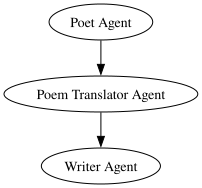

In [43]:
crew.plot()

In [44]:
crew.run()


RUNNING AGENT: Poet Agent

In whispers of wind, in shadows of night
A question echoes, a mystery in sight
What is the purpose, the reason we're here?
A query that haunts, a doubt that brings fear

Is it to seek, to find, to know and to be?
Or merely to exist, wild and carefree?
A fleeting thought, a moment's delight
Or a journey long, through the dark of night

Perhaps it's in love, in laughter and tears
In every connection, through all the years
The memories we make, the moments we share
The joy and the pain, the love that's there

Or maybe it's in the search, the quest for more
The pursuit of dreams, the drive to explore
The unknown territories of the soul
The uncharted depths, the unexplored goal

Whatever the meaning, it's unique to each
A personal truth, a subjective breach
In the tapestry of life, we're threads of gold
Interwoven, connected, young and old

So let us cherish every moment we live
Every breath, every heartbeat, every give
For in the end, it's not the years we've kn